In [18]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [2]:
df=pd.read_csv('satis_verileri.csv',sep=";")

In [3]:
df.head(4)

,DATE_,ITEMCODE,ITEMNAME,AMOUNT,UNITPRICE,PRICE,TOTALPRICE,CATEGORY1,CATEGORY2,CATEGORY3,CATEGORY4,BRAND,USERGENDER,USERBIRTHDATE,REGION,CITY,TOWN,DISTRICT
0,2021-07-08,45022,KITAP AHUDUDU KOKULU MASALLAR,3.0,64.50,43.58,130.74,EV,KITAP-DERGI-KIRTASIYE,KITAP,KITAPLAR,KITAPLAR,K,1954-06-13,Marmara,Bursa,OSMANGAZİ,KÜÇÜKBALIKLI MAH.
1,2021-01-17,7302,ULKER ONEO 2163-09 CILEK SISE DRAJE SAKIZ 60 GR,6.0,29.40,14.50,87.00,SEKERLEME,SAKIZ-SEKERLEME,SAKIZ,SAKIZLAR,ULKER,K,1985-06-21,Marmara,Çanakkale,AYVACIK/ÇANAKKALE,ÜMMÜHAN MAH.
2,2023-03-23,9544,PENG.RECEL 1800 GR CILEK*6*,7.0,86.85,91.38,639.66,KAHVALTILIK,BAL-RECEL,RECEL,CILEK,PENGUEN,K,1991-08-05,Marmara,Bilecik,BOZÜYÜK,ÇARŞI MAH.
3,2021-10-19,29435,DANONE PUD.KAKAO 200 GR *27*,4.0,7.50,5.23,20.92,SUT,DONDURMA-SUTLU TATLI,SUTLU TATLILAR,MEYVELI,DANONE,K,1997-04-02,Marmara,İstanbul,ARNAVUTKÖY,SAZLIBOSNA MAH.


In [4]:
df.describe()

,ITEMCODE,AMOUNT,UNITPRICE,PRICE,TOTALPRICE
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,22185.719740,4.508850,65.497538,57.711859,259.970399
std,12557.839717,2.289435,127.197308,116.642137,592.252009
min,5.000000,1.000000,0.000000,0.000000,0.000000
25%,11290.000000,3.000000,15.150000,12.710000,42.800000
50%,22123.500000,4.000000,35.400000,30.630000,115.850000
75%,32586.250000,7.000000,78.100000,68.100000,289.705000
max,45157.000000,8.000000,6302.300000,6953.630000,43166.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   DATE_          100000 non-null  object 
 1   ITEMCODE       100000 non-null  int64  
 2   ITEMNAME       100000 non-null  object 
 3   AMOUNT         100000 non-null  float64
 4   UNITPRICE      100000 non-null  float64
 5   PRICE          100000 non-null  float64
 6   TOTALPRICE     100000 non-null  float64
 7   CATEGORY1      100000 non-null  object 
 8   CATEGORY2      100000 non-null  object 
 9   CATEGORY3      100000 non-null  object 
 10  CATEGORY4      99694 non-null   object 
 11  BRAND          99997 non-null   object 
 12  USERGENDER     100000 non-null  object 
 13  USERBIRTHDATE  100000 non-null  object 
 14  REGION         100000 non-null  object 
 15  CITY           100000 non-null  object 
 16  TOWN           100000 non-null  object 
 17  DISTRICT       100000 non-null

In [6]:
df.dtypes

DATE_             object
ITEMCODE           int64
ITEMNAME          object
AMOUNT           float64
UNITPRICE        float64
PRICE            float64
TOTALPRICE       float64
CATEGORY1         object
CATEGORY2         object
CATEGORY3         object
CATEGORY4         object
BRAND             object
USERGENDER        object
USERBIRTHDATE     object
REGION            object
CITY              object
TOWN              object
DISTRICT          object
dtype: object

In [7]:
df['DATE_']=pd.to_datetime(df['DATE_'])

In [8]:
gunluk_satis=df.groupby(df['DATE_'].dt.date)['TOTALPRICE'].sum().reset_index()

In [10]:
gunluk_satis.columns=['ds','y']

In [11]:
gunluk_satis=gunluk_satis.sort_values('ds')
gunluk_satis.head()

,ds,y
0,2021-01-01,26084.16
1,2021-01-02,12662.42
2,2021-01-03,15740.11
3,2021-01-04,18879.69
4,2021-01-05,22805.29


In [12]:
model=Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False

)

In [13]:
model.fit(gunluk_satis)

14:38:02 - cmdstanpy - INFO - Chain [1] start processing
14:38:04 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
future=model.make_future_dataframe(periods=90)
forecast=model.predict(future)

In [15]:
print("\nGelecek Tahminleri (yhat = Tahmin Edilen Ciro):")
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)


Gelecek Tahminleri (yhat = Tahmin Edilen Ciro):


,ds,yhat,yhat_lower,yhat_upper
1036,2023-11-03,28733.263970,19740.167450,36967.515179
1037,2023-11-04,29130.211880,20667.884621,38064.450204
1038,2023-11-05,28601.703507,20067.117657,36905.572730
1039,2023-11-06,29939.972394,20540.092434,38504.031065
1040,2023-11-07,29083.223733,20815.174652,37868.885653
1041,2023-11-08,28960.130895,20679.648046,37602.926979
1042,2023-11-09,29321.879965,21086.174057,37466.459000
1043,2023-11-10,28947.820684,20193.653151,37623.033974
1044,2023-11-11,29452.902654,21083.165891,37629.511954
1045,2023-11-12,29017.026096,20577.913091,37720.798275


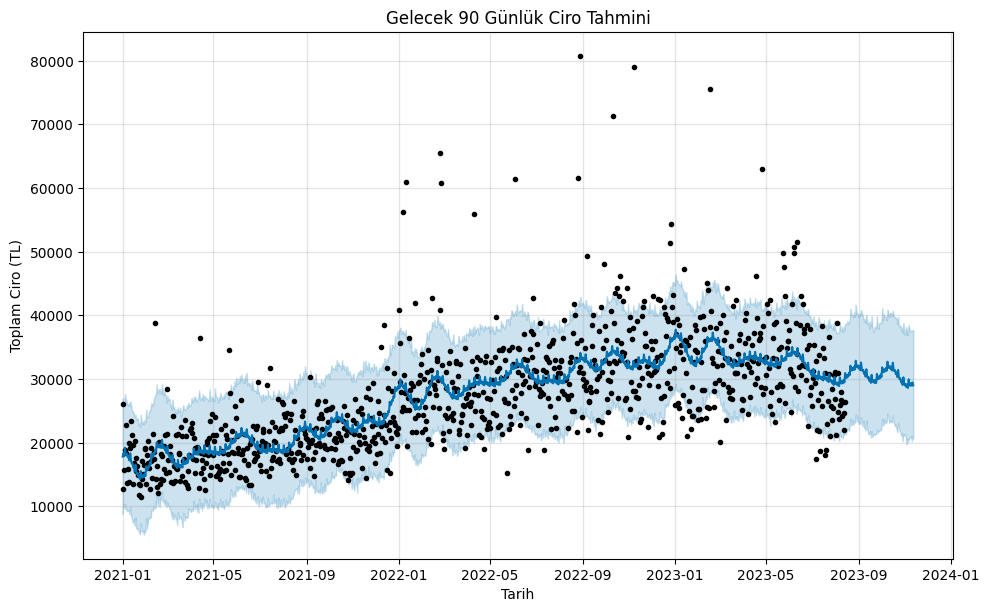

In [16]:
fig1 = model.plot(forecast)
plt.title('Gelecek 90 Günlük Ciro Tahmini')
plt.xlabel('Tarih')
plt.ylabel('Toplam Ciro (TL)')
plt.show()

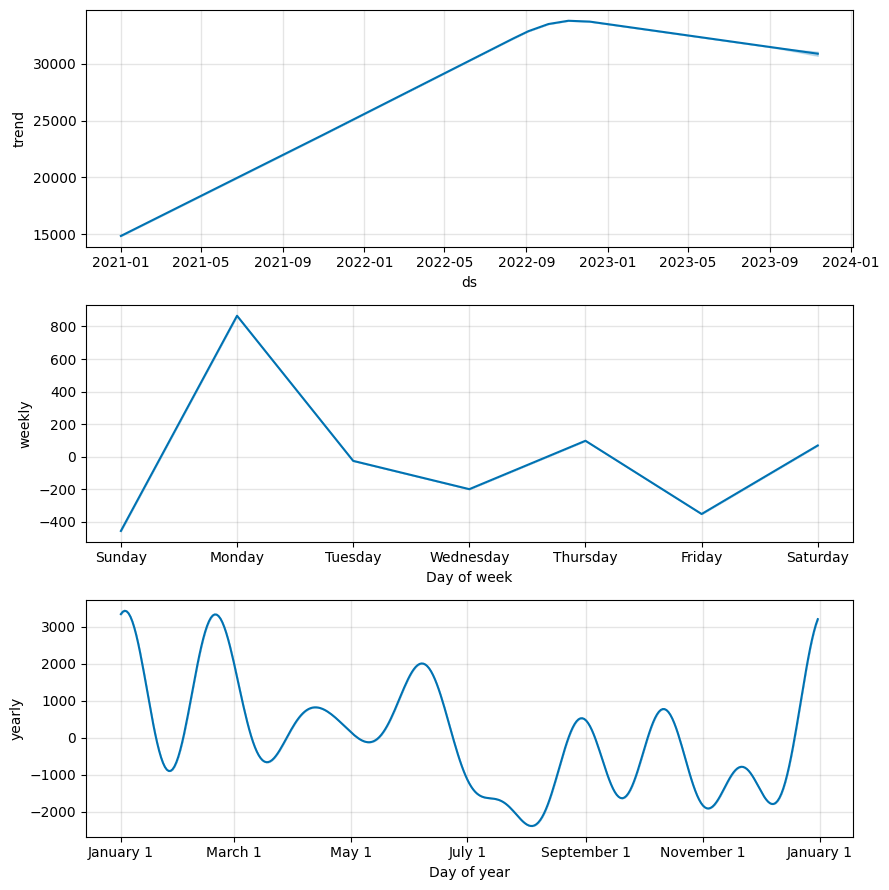

In [17]:
fig2 = model.plot_components(forecast)
plt.show()

In [19]:
train=gunluk_satis.iloc[:-90]
test=gunluk_satis.iloc[-90:]

In [ ]:
model_1=Prophet(yearly_seasonality=True,weekly_seasonality=True)
model_1.fit(train)
future = model.make_future_dataframe(periods=90)
test['ds'] = pd.to_datetime(test['ds'])
forecast = model.predict(future)
forecast['ds'] = pd.to_datetime(forecast['ds'])
result=test.merge(forecast[['ds','yhat']], on='ds')

22:36:15 - cmdstanpy - INFO - Chain [1] start processing
22:36:16 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\durha\AppData\Local\Temp\ipykernel_8752\4101961229.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds'] = pd.to_datetime(test['ds'])


In [25]:
# 1. MAE (Mean Absolute Error): Ortalama kaç TL sapma yapıyoruz?
mae = mean_absolute_error(result['y'], result['yhat'])

In [27]:
# 2. MAPE (Mean Absolute Percentage Error): Yüzdesel Ortalama Hata
mape = np.mean(np.abs((result['y'] - result['yhat']) / result['y'])) * 100

# 3. Accuracy Rate (Tahmin Doğruluk Oranı %)
accuracy = 100 - mape

print(f"Ortalama Hata Miktarı (MAE): {mae:.2f} TL")
print(f"Yüzdesel Ortalama Hata (MAPE): %{mape:.2f}")
print(f"🎯 Model Tahmin Doğruluk Oranı: %{accuracy:.2f}")

Ortalama Hata Miktarı (MAE): 5273.82 TL
Yüzdesel Ortalama Hata (MAPE): %17.90
🎯 Model Tahmin Doğruluk Oranı: %82.10


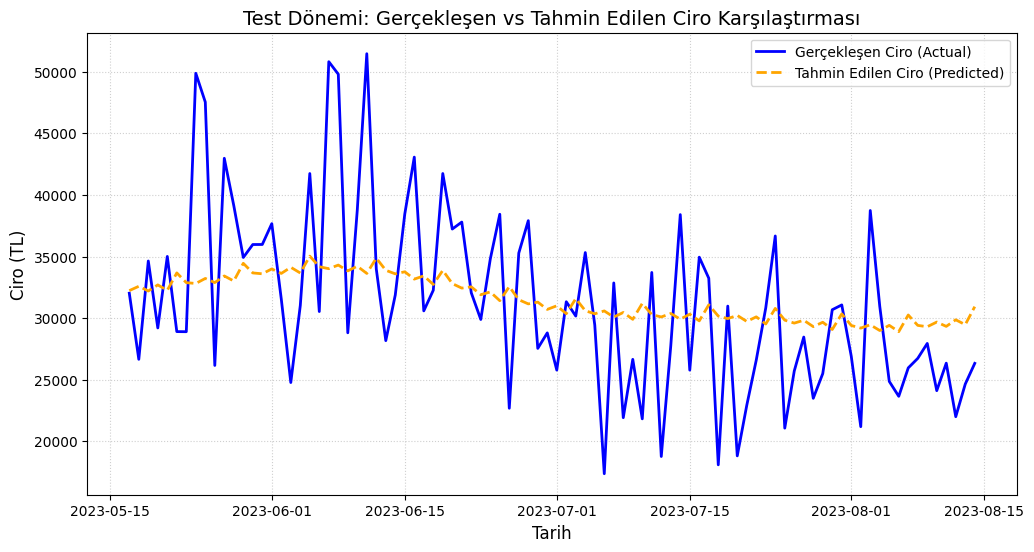

In [29]:
plt.figure(figsize=(12, 6))

# Gerçek değerler (Test seti)
plt.plot(
    result['ds'],
    result['y'],
    label='Gerçekleşen Ciro (Actual)',
    color='blue',
    linewidth=2,
)

# Modelin tahminleri
plt.plot(
    result['ds'],
    result['yhat'],
    label='Tahmin Edilen Ciro (Predicted)',
    color='orange',
    linestyle='--',
    linewidth=2,
)

plt.title(
    'Test Dönemi: Gerçekleşen vs Tahmin Edilen Ciro Karşılaştırması', fontsize=14
)
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Ciro (TL)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Grafiği kaydetme
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()